**Project: NYC Taxi Revenue Analysis**

In [ ]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load Dataset

df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/uber-rides-data1.csv')

print("Shape:\n", df.shape)
print("\nFirst five rows:\n", df.head())
print("\nDescribe Dataset:\n", df.describe())
print("\nMissing Values:\n", df.isna().sum())
print("\nInfo:\n", df.info())
print("\nColmuns:\n", df.columns.tolist())

Shape:
 (1511443, 3)

First five rows:
              Date/Time      Lat      Lon
0  2014-04-01 00:11:00  40.7690 -73.9549
1  2014-04-01 00:17:00  40.7267 -74.0345
2  2014-04-01 00:21:00  40.7316 -73.9873
3  2014-04-01 00:28:00  40.7588 -73.9776
4  2014-04-01 00:33:00  40.7594 -73.9722

Describe Dataset:
                 Lat           Lon
count  1.511443e+06  1.511443e+06
mean   4.074007e+01 -7.397550e+01
std    3.721601e-02  5.337257e-02
min    4.006820e+01 -7.492900e+01
25%    4.072240e+01 -7.399730e+01
50%    4.074320e+01 -7.398410e+01
75%    4.076120e+01 -7.396870e+01
max    4.211660e+01 -7.206660e+01

Missing Values:
 Date/Time    0
Lat          0
Lon          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511443 entries, 0 to 1511442
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Date/Time  1511443 non-null  object 
 1   Lat        1511443 non-null  float64
 2   Lon        1511443 non-null

In [ ]:
#Converting to datetime

df['Date/Time'] = pd.to_datetime(df['Date/Time'])


#Now converting to hour, day, weekday, month
df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day
df['weekday'] = df['Date/Time'].dt.weekday
df['month'] = df['Date/Time'].dt.month

print(df[['Date/Time', 'hour', 'day', 'weekday', 'month']].head())

            Date/Time  hour  day  weekday  month
0 2014-04-01 00:11:00     0    1        1      4
1 2014-04-01 00:17:00     0    1        1      4
2 2014-04-01 00:21:00     0    1        1      4
3 2014-04-01 00:28:00     0    1        1      4
4 2014-04-01 00:33:00     0    1        1      4


In [ ]:
# Hourly Demand

#counting pickups per hour
hourly_demand = df.groupby("hour").size().reset_index(name = 'pickups')

#Max and Min pickups per hour
max_pickups = hourly_demand.loc[hourly_demand['pickups'].idxmax()]
min_pickups = hourly_demand.loc[hourly_demand['pickups'].idxmin()]


print(hourly_demand)
print("\nMax pickups:\n", max_pickups)
print("\nMin pickups:\n", min_pickups)

    hour  pickups
0      0    32091
1      1    19825
2      2    12960
3      3    13995
4      4    16467
5      5    25574
6      6    49318
7      7    65862
8      8    61362
9      9    49126
10    10    49231
11    11    51560
12    12    54419
13    13    63323
14    14    77038
15    15    97288
16    16   112785
17    17   119615
18    18   112022
19    19    98287
20    20    94628
21    21    97249
22    22    81697
23    23    55721

Max pickups:
 hour           17
pickups    119615
Name: 17, dtype: int64

Min pickups:
 hour           2
pickups    12960
Name: 2, dtype: int64


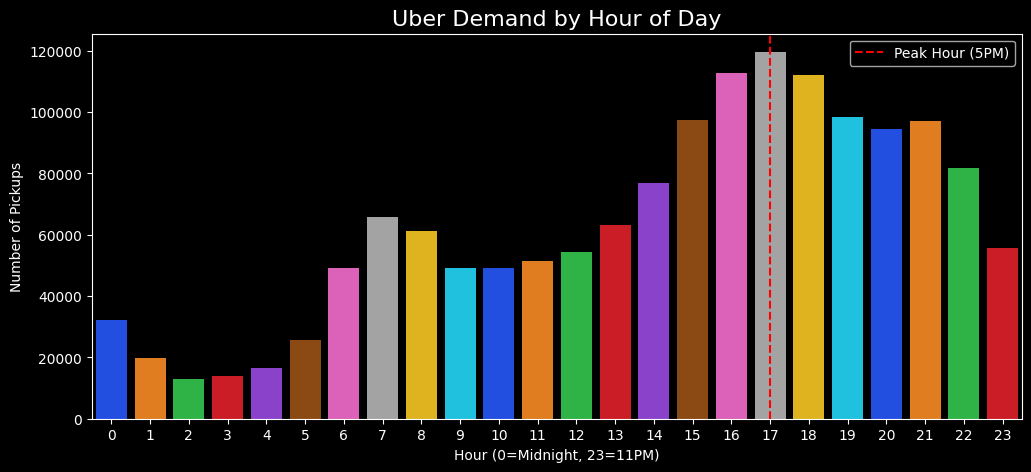

In [82]:
# Plotting the pickups per hour
plt.style.use('dark_background')
plt.figure(figsize=(12,5))
sns.barplot(x=hourly_demand['hour'],
            y=hourly_demand['pickups'],
            hue=hourly_demand['hour'],
            palette='bright',
            legend=False)
plt.title('Uber Demand by Hour of Day', fontsize=16)
plt.xlabel('Hour (0=Midnight, 23=11PM)')
plt.ylabel('Number of Pickups')
plt.axvline(x=17, color='red',
            linestyle='--', label='Peak Hour (5PM)')
plt.legend()
plt.show()

In [ ]:
#Checking which day of the week has the highest demand


#counting pickups per day

demand_per_weekday = df.groupby('weekday').size().reset_index(name = 'pickups')


#Mapping days

day_names = {0:"Mon", 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}

demand_per_weekday['day_name'] = demand_per_weekday['weekday'].map(day_names)


#Max and Min pickup days

max_demand_day = demand_per_weekday.loc[demand_per_weekday['pickups'].idxmax()]

min_demand_day = demand_per_weekday.loc[demand_per_weekday['pickups'].idxmin()]



print(demand_per_weekday)

print("\nMax demand day\n", max_demand_day)

print("\nMin demand day\n", min_demand_day)



   weekday  pickups day_name
0        0   168036      Mon
1        1   210374      Tue
2        2   245537      Wed
3        3   262580      Thu
4        4   267326      Fri
5        5   213439      Sat
6        6   144151      Sun

Max demand day
 weekday          4
pickups     267326
day_name       Fri
Name: 4, dtype: object

Min demand day
 weekday          6
pickups     144151
day_name       Sun
Name: 6, dtype: object


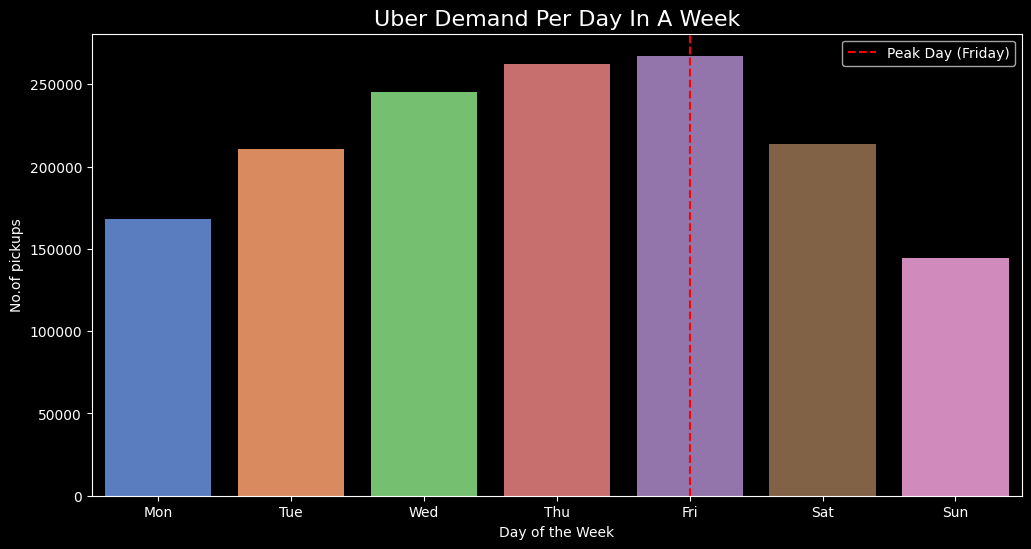

In [84]:
#Plotting demand per weekday
plt.style.use('dark_background')
plt.figure(figsize = (12,6))
sns.barplot(x = demand_per_weekday['day_name'],
            y = demand_per_weekday['pickups'],
            hue = demand_per_weekday['weekday'],
            palette = 'muted',
            legend = False)
plt.title("Uber Demand Per Day In A Week", fontsize = 16)
plt.xlabel("Day of the Week")
plt.ylabel('No.of pickups')
plt.axvline(x = 4, color = 'red',
            linestyle = '--', label = 'Peak Day (Friday)')
plt.legend()
plt.show()

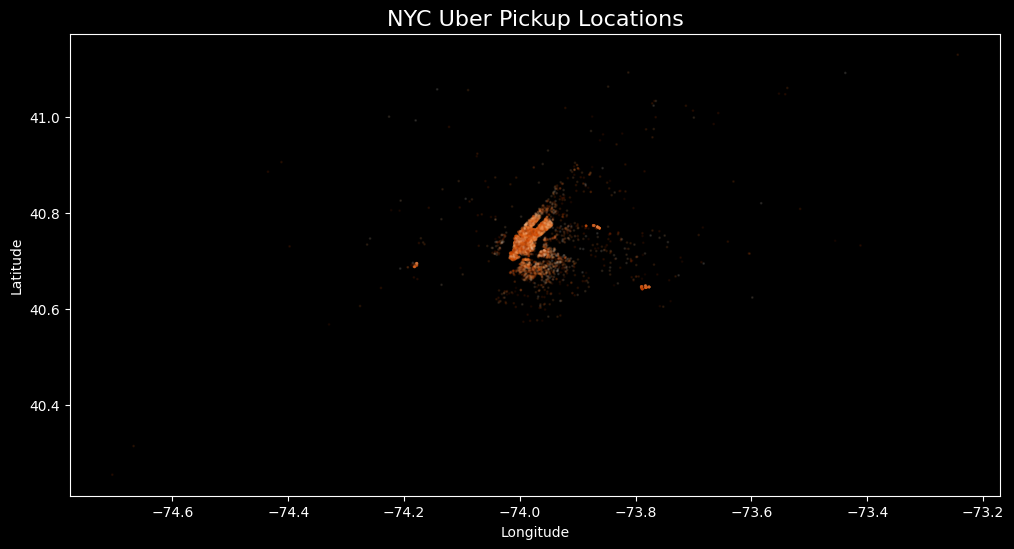

In [85]:
#Sample 10,000 points for location analysis (plotting 1.5M would crash)
sample = df.sample(10000, random_state = 42)

#plotting the sample
plt.style.use('dark_background')
plt.figure(figsize = (12,6))
plt.scatter(sample['Lon'],
            sample['Lat'],
            alpha = 0.1,
            s = 1,
            cmap = 'Oranges',
            c = sample['hour'])
plt.title("NYC Uber Pickup Locations", fontsize = 16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

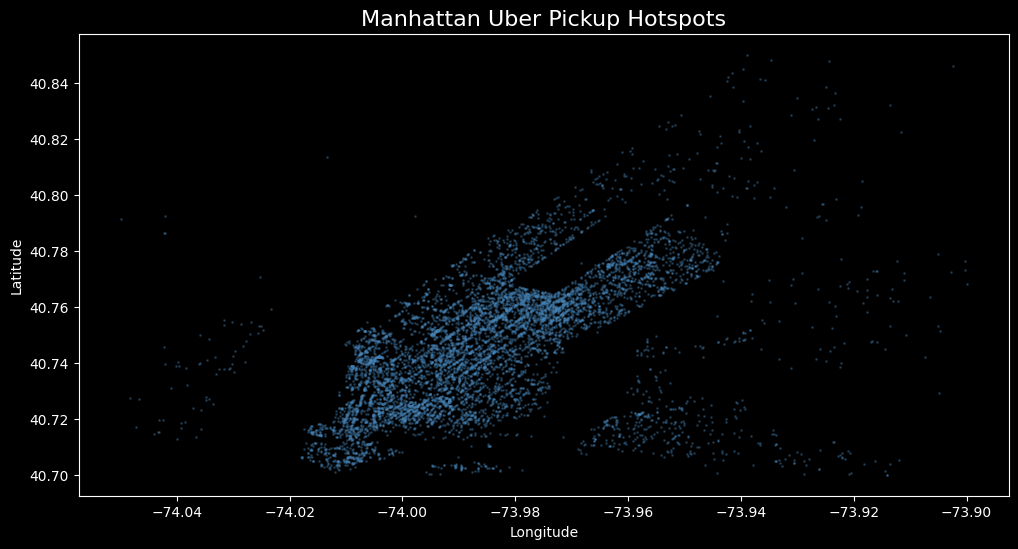

In [86]:
#Filtering Manhattan
manhattan = sample[(sample['Lat'] >= 40.70) & (sample['Lat'] <= 40.85) &
                   (sample['Lon'] >= -74.05) & (sample['Lon'] <= -73.90)]

#Plotting the Manhattan
plt.style.use('dark_background')
plt.figure(figsize = (12,6))
plt.scatter(manhattan['Lon'],
            manhattan['Lat'],
            alpha = 0.3,
            s = 1,
            color = 'steelblue')
plt.title("Manhattan Uber Pickup Hotspots", fontsize = 16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

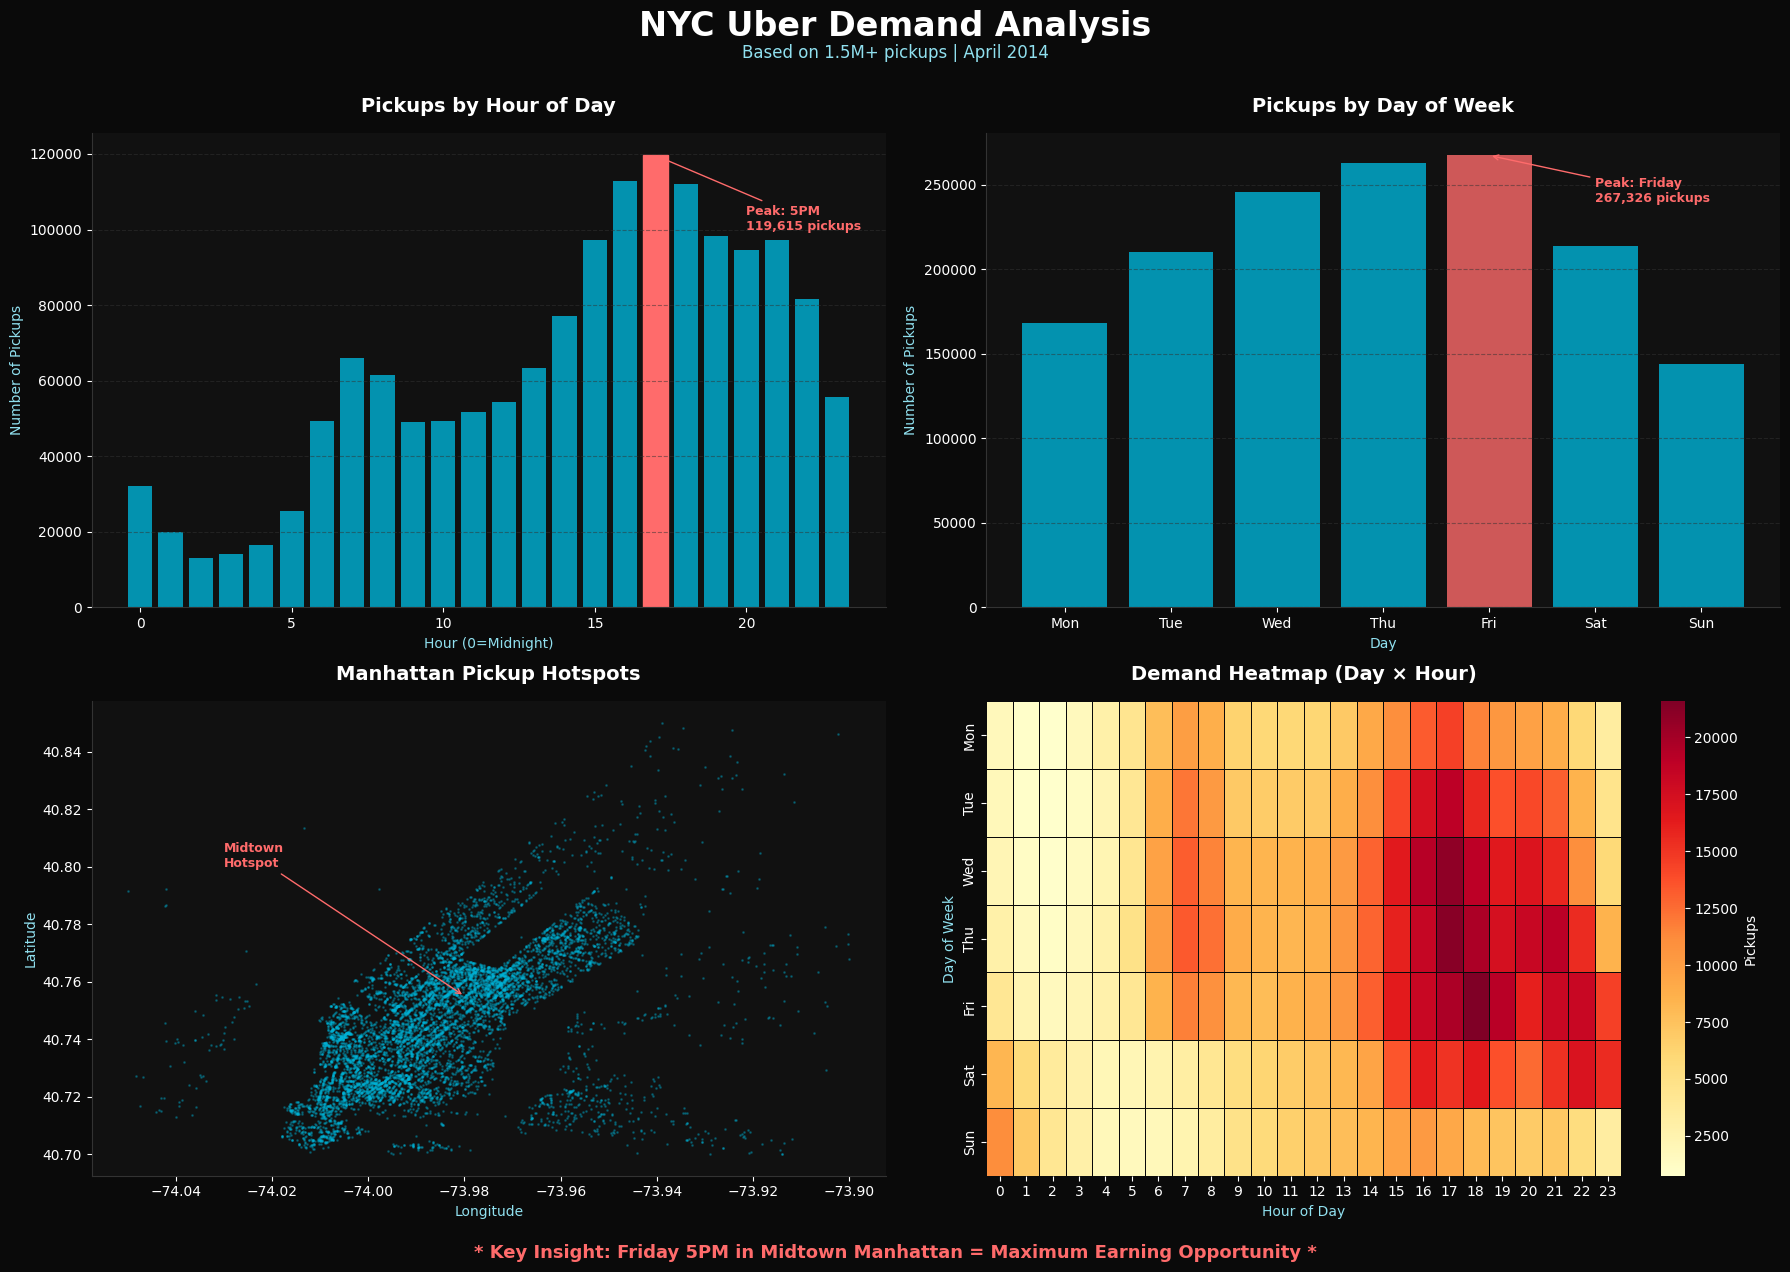

In [88]:
# Final Dashboard
plt.style.use('dark_background')
colors = ['#00B4D8', '#0077B6', '#023E8A',
          '#48CAE4', '#90E0EF', '#ADE8F4']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor('#0A0A0A')
fig.suptitle('NYC Uber Demand Analysis',
             fontsize=24,
             fontweight='bold',
             color='white',
             y=1.02)

# Subtitle
fig.text(0.5, 0.98,
         'Based on 1.5M+ pickups | April 2014',
         ha='center',
         fontsize=12,
         color='#90E0EF')

#---------------------------------------
# Chart 1 — Hourly Demand
#----------------------------------------
bars = axes[0,0].bar(hourly_demand['hour'],
                     hourly_demand['pickups'],
                     color='#00B4D8',
                     edgecolor='none',
                     alpha=0.8)

# Highlight peak bar differently
bars[17].set_color('#FF6B6B')
bars[17].set_alpha(1.0)

axes[0,0].set_facecolor('#111111')
axes[0,0].set_title('Pickups by Hour of Day',
                     color='white', fontsize=14,
                     fontweight='bold', pad=15)
axes[0,0].set_xlabel('Hour (0=Midnight)',
                      color='#90E0EF', fontsize=10)
axes[0,0].set_ylabel('Number of Pickups',
                      color='#90E0EF', fontsize=10)
axes[0,0].tick_params(colors='white')
axes[0,0].spines['bottom'].set_color('#333333')
axes[0,0].spines['left'].set_color('#333333')
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)
axes[0,0].yaxis.grid(True,
                      color='#333333',
                      linestyle='--',
                      alpha=0.5)

# Add annotation
axes[0,0].annotate('Peak: 5PM\n119,615 pickups',
                    xy=(17, 119615),
                    xytext=(20, 100000),
                    color='#FF6B6B',
                    fontsize=9,
                    fontweight='bold',
                    arrowprops=dict(arrowstyle='->',
                                   color='#FF6B6B'))

#---------------------------------
# Chart 2 — Daily Demand
#---------------------------------
day_colors = ['#00B4D8'] * 7
day_colors[4] = '#FF6B6B'  # Friday highlighted

axes[0,1].bar(demand_per_weekday['day_name'],
              demand_per_weekday['pickups'],
              color=day_colors,
              edgecolor='none',
              alpha=0.8)

axes[0,1].set_facecolor('#111111')
axes[0,1].set_title('Pickups by Day of Week',
                     color='white', fontsize=14,
                     fontweight='bold', pad=15)
axes[0,1].set_xlabel('Day',
                      color='#90E0EF', fontsize=10)
axes[0,1].set_ylabel('Number of Pickups',
                      color='#90E0EF', fontsize=10)
axes[0,1].tick_params(colors='white')
axes[0,1].spines['bottom'].set_color('#333333')
axes[0,1].spines['left'].set_color('#333333')
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].yaxis.grid(True,
                      color='#333333',
                      linestyle='--',
                      alpha=0.5)

axes[0,1].annotate('Peak: Friday\n267,326 pickups',
                    xy=(4, 267326),
                    xytext=(5, 240000),
                    color='#FF6B6B',
                    fontsize=9,
                    fontweight='bold',
                    arrowprops=dict(arrowstyle='->',
                                   color='#FF6B6B'))

#-----------------------------------
# Chart 3 — Manhattan Map
#-----------------------------------
axes[1,0].scatter(manhattan['Lon'],
                  manhattan['Lat'],
                  alpha=0.3,
                  s=1,
                  c='#00B4D8')
axes[1,0].set_facecolor('#111111')
axes[1,0].set_title('Manhattan Pickup Hotspots',
                     color='white', fontsize=14,
                     fontweight='bold', pad=15)
axes[1,0].set_xlabel('Longitude',
                      color='#90E0EF', fontsize=10)
axes[1,0].set_ylabel('Latitude',
                      color='#90E0EF', fontsize=10)
axes[1,0].tick_params(colors='white')
axes[1,0].spines['bottom'].set_color('#333333')
axes[1,0].spines['left'].set_color('#333333')
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

# Add hotspot annotation
axes[1,0].annotate('Midtown\nHotspot',
                    xy=(-73.98, 40.755),
                    xytext=(-74.03, 40.80),
                    color='#FF6B6B',
                    fontsize=9,
                    fontweight='bold',
                    arrowprops=dict(arrowstyle='->',
                                   color='#FF6B6B'))

#---------------------------------
# Chart 4 — Heatmap
#---------------------------------
pivot = df.groupby(['weekday','hour']).size().unstack()
pivot.index = ['Mon','Tue','Wed',
               'Thu','Fri','Sat','Sun']

sns.heatmap(pivot,
            cmap='YlOrRd',
            ax=axes[1,1],
            linewidths=0.5,
            linecolor='#0A0A0A',
            cbar_kws={'label': 'Pickups'})

axes[1,1].set_facecolor('#111111')
axes[1,1].set_title('Demand Heatmap (Day × Hour)',
                     color='white', fontsize=14,
                     fontweight='bold', pad=15)
axes[1,1].set_xlabel('Hour of Day',
                      color='#90E0EF', fontsize=10)
axes[1,1].set_ylabel('Day of Week',
                      color='#90E0EF', fontsize=10)
axes[1,1].tick_params(colors='white')

#---------------------------------
# Bottom insight text
#---------------------------------
fig.text(0.5, -0.02,
         '* Key Insight: Friday 5PM in Midtown Manhattan = Maximum Earning Opportunity *',
         ha='center',
         fontsize=13,
         color='#FF6B6B',
         fontweight='bold')

plt.tight_layout()
plt.savefig('nyc_uber_dashboard.png',
            dpi=150,
            bbox_inches='tight',
            facecolor='#0A0A0A')
plt.show()

## Key Findings & Recommendations

### Finding 1: Peak Hours
- Demand peaks at 5PM with 119,615 pickups
- 9.2x more demand than slowest hour (2AM)
- RECOMMENDATION: Drivers should be available
  2PM-7PM daily for maximum earnings

### Finding 2: Peak Day
- Friday has 267,326 pickups — busiest day
- Sunday has 144,151 — slowest day  
- RECOMMENDATION: Full-time drivers should
  prioritize Friday shifts

### Finding 3: Location Strategy
- Manhattan accounts for majority of pickups
- Midtown (Lat 40.74-40.78) is densest cluster
- RECOMMENDATION: Position in Midtown Manhattan
  on Friday 5PM for maximum earning potential

### Ultimate Strategy:
"Friday, 5PM, Midtown Manhattan =
 Maximum Uber earnings"